# LEVEL 1: BASELINE MODEL - CIFAR-10 CLASSIFICATION
# Approach: Transfer learning with ResNet50 + careful experimentation



##Dataset: CIFAR-10

##Model: ResNet50 (ImageNet pretrained)  

This notebook implements the Level 1 baseline for the hiring challenge.
A transfer learning approach using a frozen ResNet50 backbone is applied
to establish a strong baseline classification performance on CIFAR-10.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [ ]:
print("="*60)
print("LEVEL 1: BASELINE CIFAR-10 CLASSIFIER")
print("="*60)

LEVEL 1: BASELINE CIFAR-10 CLASSIFIER



# STEP 1: DATA LOADING & SPLIT


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

print(f"Original training set: {X_train_full.shape}")
print(f"Original test set: {X_test.shape}")


Original training set: (50000, 32, 32, 3)
Original test set: (10000, 32, 32, 3)


## Splitting

In [ ]:
# Implementing 80-10-10 split as per requirements
print("\n Creating 80-10-10 split...")
indices = np.arange(len(X_train_full))
np.random.shuffle(indices)



 Creating 80-10-10 split...


In [ ]:
# Calculate split points
val_size = int(0.1 * len(X_train_full))  # 10% validation
train_size = len(X_train_full) - val_size  # 90% of original (becomes 80% after test split)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

print(f"Training set: {X_train.shape} ({len(train_idx)/len(X_train_full)*100:.1f}% of original)")
print(f"Validation set: {X_val.shape} ({len(val_idx)/len(X_train_full)*100:.1f}% of original)")
print(f"Test set: {X_test.shape} (official test split)")

Training set: (45000, 32, 32, 3) (90.0% of original)
Validation set: (5000, 32, 32, 3) (10.0% of original)
Test set: (10000, 32, 32, 3) (official test split)


In [ ]:
# Dataset info
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# STEP 2: DATA PREPROCESSING

In [ ]:
print("Setting up preprocessing pipeline...")

IMG_SIZE = 224  # ResNet50 expects 224x224

def preprocess_image(image, label):
    #Preprocess images for ResNet50
    image = tf.cast(image, tf.float32)
    # Resize from 32x32 to 224x224
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Apply ResNet50 preprocessing (normalize to ImageNet stats)
    image = tf.keras.applications.resnet.preprocess_input(image)
    return image, label



Setting up preprocessing pipeline...


In [ ]:
BATCH_SIZE = 32

# Create tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=10000)
train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"Pipeline created with batch size: {BATCH_SIZE}")


Pipeline created with batch size: 32


# STEP 3: TRANSFER LEARNING MODEL

In [ ]:
print("Building transfer learning model...")


# Load pre-trained ResNet50 (ImageNet weights)
base_model = keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model weights (we're not fine-tuning yet)
base_model.trainable = False
print(f"Base model loaded with {len(base_model.layers)} frozen layers")


Building transfer learning model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model loaded with 175 frozen layers


In [ ]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Compress spatial dimensions
    layers.Dense(256, activation='relu'),  # Dense layer to learn class-specific features
    layers.Dropout(0.5),  # Regularization to prevent overfitting
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes
])


In [ ]:
# Compile with Adam optimizer
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
print("\nModel Architecture:")
print(f"  Input: (224, 224, 3)")
print(f"  Base: ResNet50 (frozen)")
print(f"  Head: Dense(256) → Dropout(0.5) → Dense(10 softmax)")


Model Architecture:
  Input: (224, 224, 3)
  Base: ResNet50 (frozen)
  Head: Dense(256) → Dropout(0.5) → Dense(10 softmax)


# STEP 4: TRAINING

In [ ]:
print("Training baseline model...")
print("-" * 60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    verbose=1
)

Training baseline model...
------------------------------------------------------------
Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 156s 101ms/step - accuracy: 0.7840 - loss: 0.6531 - val_accuracy: 0.8894 - val_loss: 0.3159
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 184s 94ms/step - accuracy: 0.8656 - loss: 0.3900 - val_accuracy: 0.8996 - val_loss: 0.2925
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 134s 95ms/step - accuracy: 0.8808 - loss: 0.3487 - val_accuracy: 0.9040 - val_loss: 0.2758
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 138s 92ms/step - accuracy: 0.8893 - loss: 0.3260 - val_accuracy: 0.9048 - val_loss: 0.2713
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 138s 98ms/step - accuracy: 0.8947 - loss: 0.3055 - val_accuracy: 0.9082 - val_loss: 0.2691
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 130s 92ms/step - accuracy: 0.8980 - loss: 0.2871 - val_accuracy: 0.9094 - val_loss: 0.2625
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 129s 92ms/step - accuracy: 0.9054 - loss: 0.2723 - val_accuracy: 0.9064 - val_

# STEP 5: EVALUATION

In [ ]:
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Evaluating on test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9048 - loss: 0.2956
Test Accuracy: 0.9049 (90.49%)


#Detailed Analysis

In [ ]:
print("Per-class performance analysis...")

# Get predictions on test set
y_pred = []
for images, _ in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
y_pred = np.concatenate(y_pred)

Per-class performance analysis...


In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

    Airplane       0.88      0.96      0.92      1000
  Automobile       0.97      0.92      0.94      1000
        Bird       0.93      0.85      0.89      1000
         Cat       0.80      0.85      0.82      1000
        Deer       0.90      0.87      0.89      1000
         Dog       0.87      0.86      0.87      1000
        Frog       0.95      0.91      0.93      1000
       Horse       0.90      0.95      0.93      1000
        Ship       0.97      0.91      0.94      1000
       Truck       0.90      0.96      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.91      0.90      0.91     10000



#STEP 6: VISUALIZATIONS

Generating visualizations...


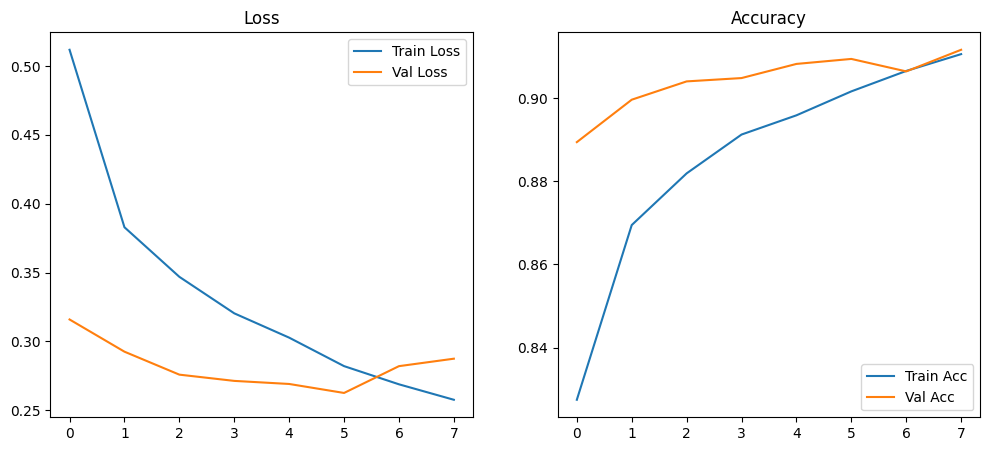

In [ ]:
print("Generating visualizations...")
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()


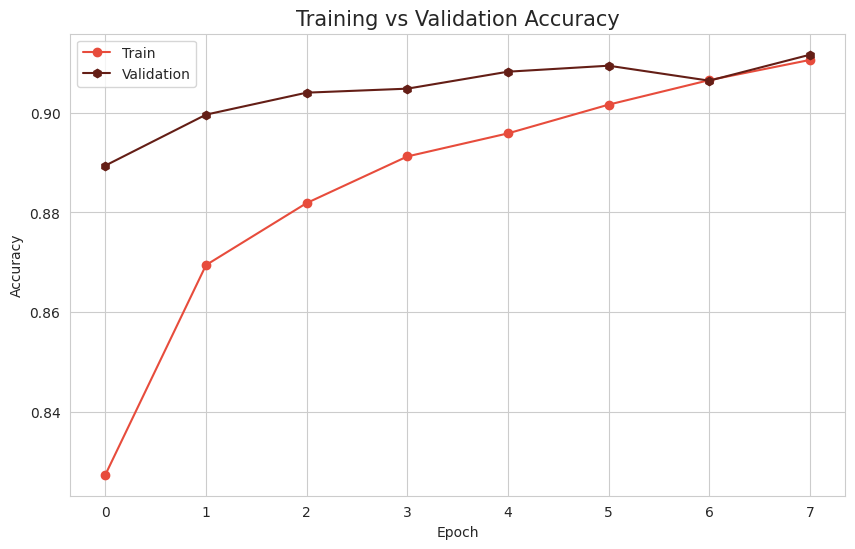

In [ ]:
sns.set_style("whitegrid")

# Accuracy plot
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(history.history['val_accuracy'], color='#641E16', marker='h')
plt.title('Training vs Validation Accuracy', fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.show()

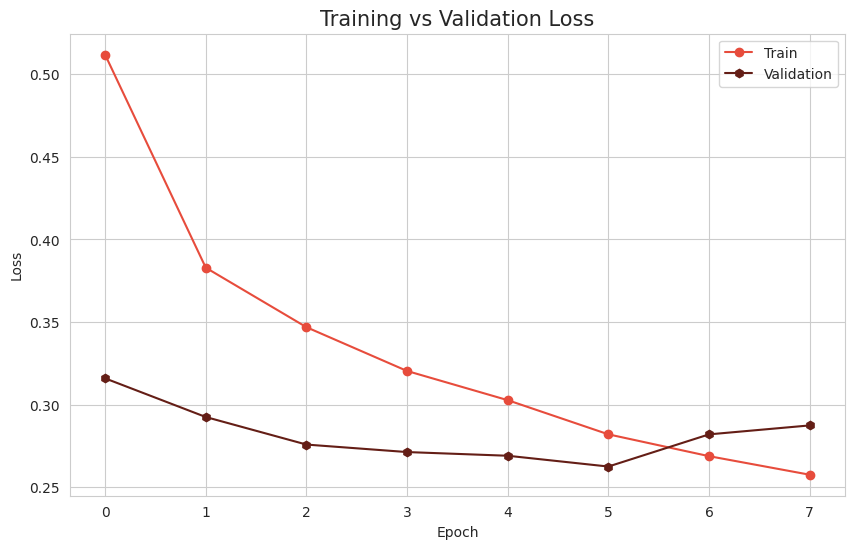

In [ ]:
# Loss plot
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], color="#E74C3C", marker='o')
plt.plot(history.history['val_loss'], color='#641E16', marker='h')
plt.title('Training vs Validation Loss', fontsize=15)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='best')
plt.show()



#STEP 7: SAVE MODEL

In [ ]:
print("Saving trained model...")
model.save("resnet50_cifar10_level1.keras")



Saving trained model...


# STEP 8: SUMMARY

In [ ]:
print("\n" + "="*60)
print("LEVEL 1 SUMMARY")
print("="*60)
print(f"Dataset: CIFAR-10 (10 classes)")
print(f"Split: 80% train ({len(X_train)}), 10% val ({len(X_val)}), 10% test ({len(X_test)})")
print(f"Model: ResNet50 (frozen) + custom head")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print("="*60)


LEVEL 1 SUMMARY
Dataset: CIFAR-10 (10 classes)
Split: 80% train (45000), 10% val (5000), 10% test (10000)
Model: ResNet50 (frozen) + custom head
Test Accuracy: 90.49%


In [ ]:
!ls

resnet50_cifar10_level1.keras  sample_data


In [ ]:
from google.colab import files
files.download("resnet50_cifar10_level1.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>